In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import optuna
import warnings
import json

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import joblib

In [2]:
# ── 폰트 ──────────────────────────────────────────────────────────────
font_path = r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\5_fonts\Pretendard-Medium.otf"
font_name = fm.FontProperties(fname=font_path).get_name()
fm.fontManager.addfont(font_path)
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
print(f'폰트: {font_name}')

폰트: Pretendard


In [3]:
# ══════════════════════════════════════════════════════════════════════
# 1. 데이터 로드
# ══════════════════════════════════════════════════════════════════════
df = pd.read_csv(r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\1_data\processed\df_final_v2.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

df['강수량(mm)'] = df['강수량(mm)'].fillna(0)
df['일사(MJ/m2)'] = df['일사(MJ/m2)'].fillna(0)

print(f'데이터 기간: {df["datetime"].min()} ~ {df["datetime"].max()}')
print(f'전체 행 수: {len(df):,}')

데이터 기간: 2023-01-08 01:00:00 ~ 2025-01-01 00:00:00
전체 행 수: 17,376


In [4]:
# ══════════════════════════════════════════════════════════════════════
# 2. 피처 엔지니어링
# ══════════════════════════════════════════════════════════════════════
TARGET = '전력사용량(MWh)'

# 냉난방 도일
if 'CDD' not in df.columns:
    df['CDD'] = np.maximum(0, df['기온(°C)'] - 24)
if 'HDD' not in df.columns:
    df['HDD'] = np.maximum(0, 18 - df['기온(°C)'])

# 폭염 플래그
df['is_heatwave'] = (df['기온(°C)'] >= 33).astype(int)

# 피크 시간대 (14~17시)
df['is_peak_hour'] = df['hour'].between(14, 17).astype(int)

# 기온 rolling
df['temp_3h_mean'] = df['기온(°C)'].shift(1).rolling(3).mean()
df['temp_6h_max']  = df['기온(°C)'].shift(1).rolling(6).max()

# 전력 lag (신규: lag_1, lag_3 추가)
df['lag_1']   = df[TARGET].shift(1)
df['lag_3']   = df[TARGET].shift(3)
df['lag_24']  = df[TARGET].shift(24)
df['lag_168'] = df[TARGET].shift(168)

# 전력 rolling
df['rolling_6h_mean']  = df[TARGET].shift(1).rolling(6).mean()
df['rolling_24h_mean'] = df[TARGET].shift(1).rolling(24).mean()
df['rolling_24h_std']  = df[TARGET].shift(1).rolling(24).std()

df = df.dropna().reset_index(drop=True)
print(f'피처 엔지니어링 후 행 수: {len(df):,}')

피처 엔지니어링 후 행 수: 17,208


In [5]:
# ══════════════════════════════════════════════════════════════════════
# 3. 피처 정의
# ══════════════════════════════════════════════════════════════════════
FEATURES_FINAL = [
    # 시간
    "hour", "dayofweek", "month", "is_holiday", "is_peak_hour",
    # 기상
    "기온(°C)", "강수량(mm)", "습도(%)", "일사(MJ/m2)",
    # 냉난방
    "CDD", "HDD", "is_heatwave",
    # 기온 패턴
    "temp_3h_mean", "temp_6h_max",
    # 전력 자기상관
    "lag_1", "lag_3", "lag_24", "lag_168",
    # 소비 패턴
    "rolling_6h_mean", "rolling_24h_mean", "rolling_24h_std",
]

FEATURES_FINAL = [f for f in FEATURES_FINAL if f in df.columns]
print(f'사용 피처 수: {len(FEATURES_FINAL)}')
print(f'피처 목록: {FEATURES_FINAL}')

사용 피처 수: 21
피처 목록: ['hour', 'dayofweek', 'month', 'is_holiday', 'is_peak_hour', '기온(°C)', '강수량(mm)', '습도(%)', '일사(MJ/m2)', 'CDD', 'HDD', 'is_heatwave', 'temp_3h_mean', 'temp_6h_max', 'lag_1', 'lag_3', 'lag_24', 'lag_168', 'rolling_6h_mean', 'rolling_24h_mean', 'rolling_24h_std']


In [6]:
# ══════════════════════════════════════════════════════════════════════
# 4. Train / Test 분리 (Train: 2023, Test: 2024)
# ══════════════════════════════════════════════════════════════════════
train = df[df['datetime'].dt.year <= 2023].copy()
test  = df[df['datetime'].dt.year == 2024].copy()

X_train = train[FEATURES_FINAL]
y_train = train[TARGET]
X_test  = test[FEATURES_FINAL]
y_test  = test[TARGET]

print(f'\nTrain: {len(train):,}행  |  Test: {len(test):,}행')


Train: 8,423행  |  Test: 8,784행


In [7]:
# ══════════════════════════════════════════════════════════════════════
# 5. 샘플 가중치 (폭염 + 피크 복합)
# ══════════════════════════════════════════════════════════════════════
def make_sample_weight(data):
    return np.where(
        (data['기온(°C)'] >= 33) & (data['hour'].between(14, 17)), 10.0,  # 폭염 + 피크
        np.where(data['기온(°C)'] >= 33, 5.0,                              # 폭염만
        np.where(data['hour'].between(14, 17), 2.0, 1.0))                  # 피크만
    )

sample_weight = make_sample_weight(train)

In [8]:
# ══════════════════════════════════════════════════════════════════════
# 6. Optuna 하이퍼파라미터 튜닝
# ══════════════════════════════════════════════════════════════════════
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 5),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample'        : trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight' : trial.suggest_int('min_child_weight', 10, 50),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1.0, 5.0),
        'random_state'     : 42,
        'n_jobs'           : -1,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    rmses = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, y_tr   = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx],   y_train.iloc[val_idx]
        sw_tr        = sample_weight[train_idx]

        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr, sample_weight=sw_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = model.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    return np.mean(rmses)


print('\nOptuna 튜닝 시작...')
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\n최적 CV RMSE : {study.best_value:.1f}')
print(f'최적 파라미터: {study.best_params}')


Optuna 튜닝 시작...


  0%|          | 0/80 [00:00<?, ?it/s]


최적 CV RMSE : 107.4
최적 파라미터: {'n_estimators': 771, 'max_depth': 4, 'learning_rate': 0.09323102560912903, 'subsample': 0.7958236512606099, 'colsample_bytree': 0.837229781434307, 'min_child_weight': 21, 'reg_alpha': 1.1444466175575982, 'reg_lambda': 1.1545706479267535}


In [9]:
# ══════════════════════════════════════════════════════════════════════
# 7. 최종 모델 학습
# ══════════════════════════════════════════════════════════════════════
best_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train, sample_weight=sample_weight)

train_pred = best_model.predict(X_train)
test_pred  = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))
train_r2   = r2_score(y_train, train_pred)
test_r2    = r2_score(y_test,  test_pred)
test_mape  = mean_absolute_percentage_error(y_test, test_pred) * 100

print('\n' + '='*50)
print(f'{"지표":<12} {"Train":>10} {"Test":>10}')
print('-'*50)
print(f'{"RMSE":<12} {train_rmse:>10.1f} {test_rmse:>10.1f}')
print(f'{"R²":<12} {train_r2:>10.4f} {test_r2:>10.4f}')
print(f'{"MAPE(%)":<12} {"-":>10} {test_mape:>10.2f}')
print(f'{"과적합 갭":<12} {test_rmse - train_rmse:>10.1f}')
print('='*50)


지표                Train       Test
--------------------------------------------------
RMSE               34.3      117.6
R²               0.9994     0.9939
MAPE(%)               -       1.15
과적합 갭              83.3



기온 구간별 성능
              샘플수   평균오차   RMSE    MAE
temp_zone                             
한랭(<10°C)    3101   36.0   72.3   52.8
보통(10~20°C)  2351   21.1   56.5   41.9
더움(20~28°C)  2325   37.1   93.9   62.2
고온(28~33°C)   906   94.1  210.5  137.3
폭염(33°C+)     101  411.8  606.0  420.8

피크/비피크 성능
             샘플수  평균오차   RMSE   MAE
time_zone                          
비피크         7320  40.4  106.2  63.8
피크(14~17시)  1464  53.7  162.8  72.6


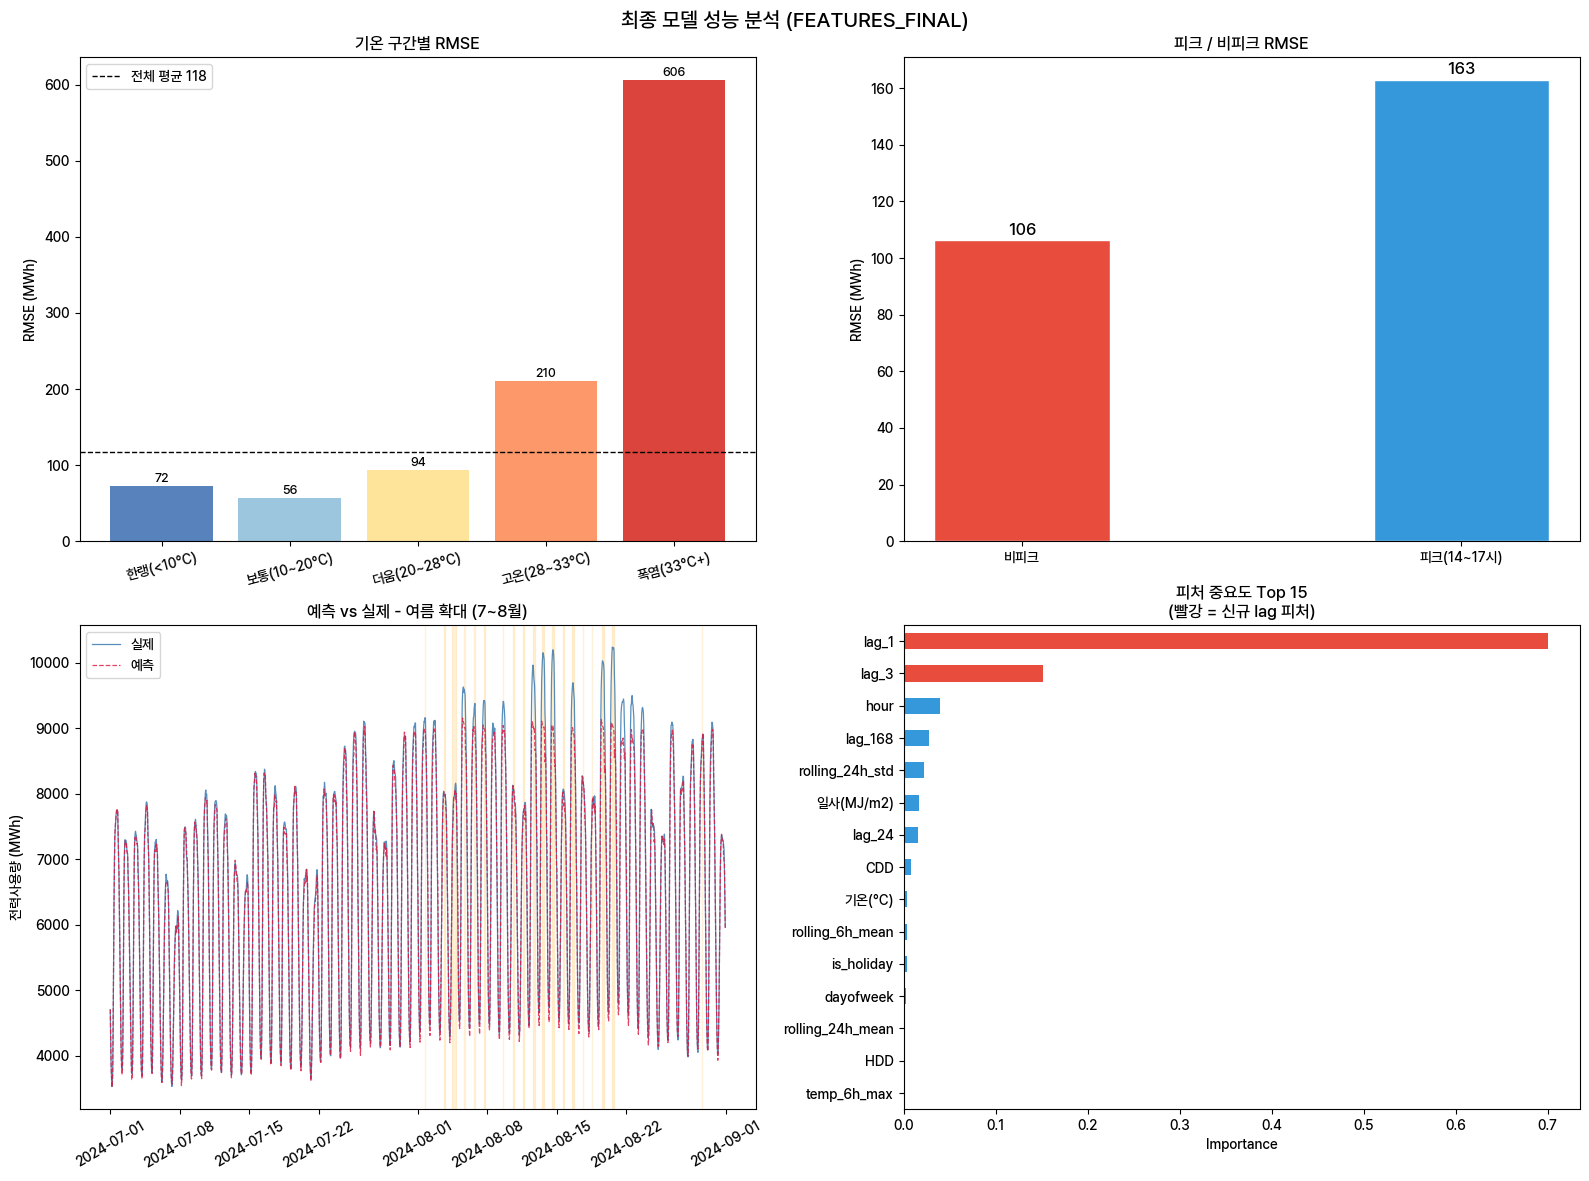

저장 완료: final_model_result.png


In [10]:
# ══════════════════════════════════════════════════════════════════════
# 8. 성능 시각화
# ══════════════════════════════════════════════════════════════════════
test_eval = test[['datetime', '기온(°C)', 'hour', TARGET]].copy()
test_eval['pred']      = test_pred
test_eval['error']     = test_eval[TARGET] - test_eval['pred']
test_eval['abs_error'] = test_eval['error'].abs()

# 기온 구간
bins   = [-np.inf, 10, 20, 28, 33, np.inf]
labels = ['한랭(<10°C)', '보통(10~20°C)', '더움(20~28°C)', '고온(28~33°C)', '폭염(33°C+)']
test_eval['temp_zone'] = pd.cut(test_eval['기온(°C)'], bins=bins, labels=labels)
test_eval['time_zone'] = np.where(test_eval['hour'].between(14, 17), '피크(14~17시)', '비피크')

zone_stats = test_eval.groupby('temp_zone', observed=True).agg(
    샘플수=('abs_error', 'count'),
    평균오차=('error', 'mean'),
    RMSE=('abs_error', lambda x: np.sqrt((x**2).mean())),
    MAE=('abs_error', 'mean')
).round(1)

peak_stats = test_eval.groupby('time_zone', observed=True).agg(
    샘플수=('abs_error', 'count'),
    평균오차=('error', 'mean'),
    RMSE=('abs_error', lambda x: np.sqrt((x**2).mean())),
    MAE=('abs_error', 'mean')
).round(1)

print('\n기온 구간별 성능')
print(zone_stats)
print('\n피크/비피크 성능')
print(peak_stats)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('최종 모델 성능 분석 (FEATURES_FINAL)', fontsize=15, fontweight='bold')
colors = ['#4575b4', '#91bfdb', '#fee090', '#fc8d59', '#d73027']

# Plot 1: 기온 구간별 RMSE
ax = axes[0, 0]
bars = ax.bar(range(len(labels)), zone_stats['RMSE'].values, color=colors, alpha=0.9)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=15)
ax.set_title('기온 구간별 RMSE')
ax.set_ylabel('RMSE (MWh)')
ax.axhline(test_rmse, color='black', linestyle='--', linewidth=1, label=f'전체 평균 {test_rmse:.0f}')
ax.legend()
for bar, val in zip(bars, zone_stats['RMSE'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# Plot 2: 피크 vs 비피크 RMSE
ax = axes[0, 1]
peak_colors = ['#e74c3c', '#3498db']
bars = ax.bar(peak_stats.index, peak_stats['RMSE'], color=peak_colors, edgecolor='white', width=0.4)
ax.set_title('피크 / 비피크 RMSE')
ax.set_ylabel('RMSE (MWh)')
for bar, val in zip(bars, peak_stats['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 3: 예측 vs 실제 (여름)
ax = axes[1, 0]
summer = test_eval[test_eval['datetime'].dt.month.between(7, 8)]
ax.plot(summer['datetime'], summer[TARGET], label='실제', color='steelblue', linewidth=0.9, alpha=0.9)
ax.plot(summer['datetime'], summer['pred'],  label='예측', color='crimson',   linewidth=0.9, alpha=0.8, linestyle='--')
heatwave_mask = summer['기온(°C)'] >= 33
if heatwave_mask.any():
    for _, group in summer[heatwave_mask].groupby((~heatwave_mask).cumsum()):
        ax.axvspan(group['datetime'].iloc[0], group['datetime'].iloc[-1], alpha=0.15, color='orange')
ax.set_title('예측 vs 실제 - 여름 확대 (7~8월)')
ax.set_ylabel('전력사용량 (MWh)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Plot 4: 피처 중요도 Top 15
ax = axes[1, 1]
importance = pd.Series(best_model.feature_importances_, index=FEATURES_FINAL)
top15 = importance.nlargest(15)
bar_colors = ['#e74c3c' if f in ['lag_1', 'lag_3'] else '#3498db' for f in top15.index]
top15.sort_values().plot(kind='barh', ax=ax, color=bar_colors[::-1])
ax.set_title('피처 중요도 Top 15\n(빨강 = 신규 lag 피처)')
ax.set_xlabel('Importance')

plt.tight_layout()
OUTPUT_DIR = r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\4_outputs\10_final"
plt.savefig(OUTPUT_DIR + r"\final_model_result.png", dpi=300, bbox_inches='tight')
plt.show()
print('저장 완료: final_model_result.png')

In [11]:
# ══════════════════════════════════════════════════════════════════════
# 9. 모델 & 피처 저장
# ══════════════════════════════════════════════════════════════════════
MODEL_DIR = r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\6_models"

joblib.dump(best_model, MODEL_DIR + r"\xgb_power_model_v2.pkl")
print('모델 저장 완료: xgb_power_model_v2.pkl')

with open(MODEL_DIR + r"\features_v2.json", 'w', encoding='utf-8') as f:
    json.dump(FEATURES_FINAL, f, ensure_ascii=False, indent=2)
print('피처 저장 완료: features_v2.json')

# 예측 결과 저장 (대시보드용)
df_result = test[['datetime'] + FEATURES_FINAL + [TARGET]].copy()
df_result['pred'] = test_pred
df_result.to_csv(
    r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\1_data\processed\df_predicted_final.csv",
    index=False, encoding='utf-8-sig'
)
print('예측 결과 저장 완료: df_predicted_final.csv')

print('\n✅ 전체 완료!')
print(f'   RMSE  : {test_rmse:.1f}  |  R² : {test_r2:.4f}  |  MAPE : {test_mape:.2f}%')

모델 저장 완료: xgb_power_model_v2.pkl
피처 저장 완료: features_v2.json
예측 결과 저장 완료: df_predicted_final.csv

✅ 전체 완료!
   RMSE  : 117.6  |  R² : 0.9939  |  MAPE : 1.15%
